# CHI-Bench Care Management Workflow Analysis

Descriptive analysis of the 25 Care Management benchmark workflows using extracted task metadata. The analysis focuses on condition-label structure, engagement-scenario distribution, and benchmark workflow configuration. It does not use hidden evaluation artifacts or measure model performance.


In [2]:
from pathlib import Path
import csv
from collections import Counter

PROJECT_ROOT = Path.cwd().parent.parent
DATA_FILE = PROJECT_ROOT / "analysis" / "data" / "care_management_task_metadata.csv"

with DATA_FILE.open(encoding="utf-8", newline="") as f:
    rows = list(csv.DictReader(f))

print("Care Management workflows loaded:", len(rows))

Care Management workflows loaded: 25


## 1. Workflow Metrics


In [3]:
total_workflows = len(rows)
distinct_conditions = len(set(row["condition"] for row in rows))
verifier_timeouts = Counter(float(row["verifier_timeout_sec"]) for row in rows)
agent_timeouts = Counter(float(row["agent_timeout_sec"]) for row in rows)

print("CARE MANAGEMENT WORKFLOW METRICS")
print("--------------------------------")
print("Workflows:", total_workflows)
print("Distinct condition labels:", distinct_conditions)
print("Verifier timeout values:", dict(verifier_timeouts))
print("Agent timeout values:", dict(agent_timeouts))


CARE MANAGEMENT WORKFLOW METRICS
--------------------------------
Workflows: 25
Distinct condition labels: 22
Verifier timeout values: {1200.0: 25}
Agent timeout values: {900.0: 25}


## 2. Engagement Scenario Distribution


In [4]:
engagement_counts = Counter(row["engagement_pattern"] for row in rows)

print("ENGAGEMENT SCENARIOS")
print("-------------------")
for pattern, count in sorted(engagement_counts.items(), key=lambda x: (-x[1], x[0])):
    percentage = count / total_workflows * 100
    print(f"{pattern}: {count} workflows ({percentage:.1f}%)")


ENGAGEMENT SCENARIOS
-------------------
hard_refuses: 15 workflows (60.0%)
moderate_anxious: 4 workflows (16.0%)
low_coop: 2 workflows (8.0%)
moderate_tentative: 2 workflows (8.0%)
low_tentative: 1 workflows (4.0%)
moderate_reluctant: 1 workflows (4.0%)


## 3. Condition-Label Distribution


In [5]:
condition_counts = Counter(row["condition"] for row in rows)

print("CONDITION LABELS")
print("----------------")
for condition, count in sorted(condition_counts.items(), key=lambda x: (-x[1], x[0])):
    print(f"{condition}: {count}")

print("\nRepeated condition labels:")
for condition, count in condition_counts.items():
    if count > 1:
        print(f"{condition}: {count}")


CONDITION LABELS
----------------
dm: 3
mdd: 2
afib: 1
anorexia: 1
asthma: 1
ckd: 1
complex_esrd_dm: 1
complex_hf_afib_ckd: 1
complex_parkinson_dep: 1
copd: 1
dementia: 1
hf: 1
htn: 1
metabolic_syndrome: 1
parkinson: 1
post_hip: 1
post_mi: 1
post_pna: 1
post_stroke: 1
ptsd: 1
schizo: 1
sud: 1

Repeated condition labels:
dm: 3
mdd: 2


## 4. Engagement Scenario by Condition


In [6]:
condition_engagement = {}

for condition in sorted(condition_counts):
    patterns = Counter(
        row["engagement_pattern"]
        for row in rows
        if row["condition"] == condition
    )
    condition_engagement[condition] = dict(patterns)

for condition, patterns in condition_engagement.items():
    print(f"{condition}: {patterns}")


afib: {'moderate_anxious': 1}
anorexia: {'hard_refuses': 1}
asthma: {'low_coop': 1}
ckd: {'moderate_anxious': 1}
complex_esrd_dm: {'hard_refuses': 1}
complex_hf_afib_ckd: {'hard_refuses': 1}
complex_parkinson_dep: {'moderate_tentative': 1}
copd: {'hard_refuses': 1}
dementia: {'hard_refuses': 1}
dm: {'hard_refuses': 1, 'low_coop': 1, 'moderate_anxious': 1}
hf: {'hard_refuses': 1}
htn: {'low_tentative': 1}
mdd: {'hard_refuses': 1, 'moderate_reluctant': 1}
metabolic_syndrome: {'hard_refuses': 1}
parkinson: {'hard_refuses': 1}
post_hip: {'moderate_anxious': 1}
post_mi: {'hard_refuses': 1}
post_pna: {'moderate_tentative': 1}
post_stroke: {'hard_refuses': 1}
ptsd: {'hard_refuses': 1}
schizo: {'hard_refuses': 1}
sud: {'hard_refuses': 1}


In [7]:
scenario_condition_table = {}

for pattern in sorted(engagement_counts):
    scenario_condition_table[pattern] = {
        condition: count
        for condition, count in condition_counts.items()
        if condition_engagement[condition].get(pattern, 0) > 0
    }

print("ENGAGEMENT SCENARIO → CONDITION LABELS")
print("---------------------------------------")

for pattern, conditions in scenario_condition_table.items():
    print(f"\n{pattern} ({engagement_counts[pattern]} workflows)")
    print(", ".join(sorted(conditions)))

ENGAGEMENT SCENARIO → CONDITION LABELS
---------------------------------------

hard_refuses (15 workflows)
anorexia, complex_esrd_dm, complex_hf_afib_ckd, copd, dementia, dm, hf, mdd, metabolic_syndrome, parkinson, post_mi, post_stroke, ptsd, schizo, sud

low_coop (2 workflows)
asthma, dm

low_tentative (1 workflows)
htn

moderate_anxious (4 workflows)
afib, ckd, dm, post_hip

moderate_reluctant (1 workflows)
mdd

moderate_tentative (2 workflows)
complex_parkinson_dep, post_pna


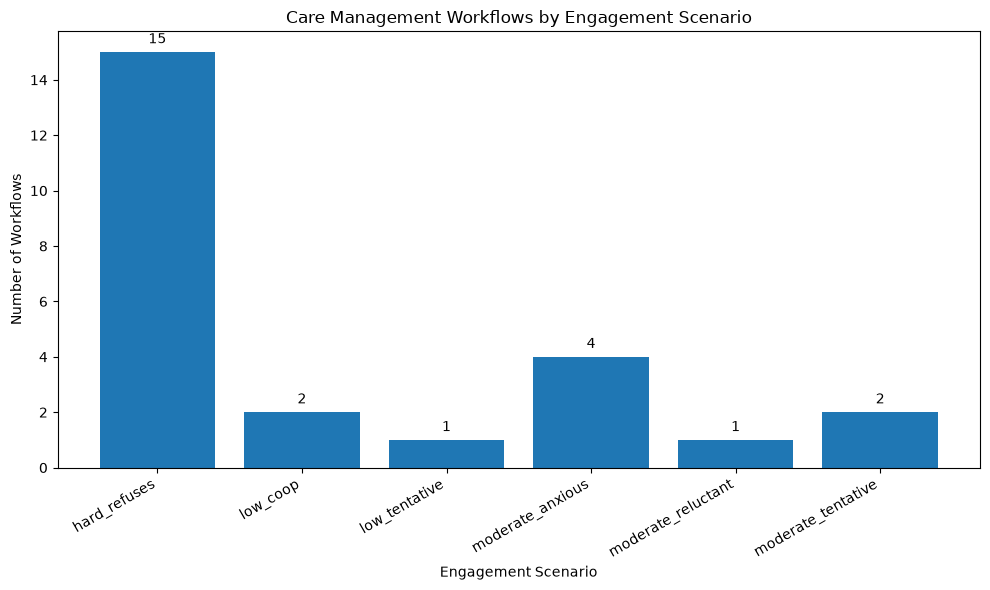

Saved: c:\Users\acharya\Desktop\CHI_Bench\chi-bench\analysis\figures\care_management_engagement_scenarios.png


In [8]:
import matplotlib.pyplot as plt

patterns = list(sorted(engagement_counts))
counts = [engagement_counts[pattern] for pattern in patterns]

plt.figure(figsize=(10, 6))
bars = plt.bar(patterns, counts)

plt.title("Care Management Workflows by Engagement Scenario")
plt.xlabel("Engagement Scenario")
plt.ylabel("Number of Workflows")
plt.xticks(rotation=30, ha="right")

for bar, value in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.2,
        str(value),
        ha="center",
        va="bottom",
    )

plt.tight_layout()

FIGURES_DIR = PROJECT_ROOT / "analysis" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

output_path = FIGURES_DIR / "care_management_engagement_scenarios.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", output_path)

## Key Observations

- The Care Management domain contains 25 benchmark workflows spanning 22 condition labels.
- `hard_refuses` is the most frequent engagement scenario, representing 15 of 25 workflows (60%).
- The remaining workflows are distributed across moderate-anxious, low-cooperation, moderate-tentative, low-tentative, and moderate-reluctant scenarios.
- Diabetes (`dm`) appears in three workflows with three different engagement scenarios: `hard_refuses`, `low_coop`, and `moderate_anxious`.
- Major depressive disorder (`mdd`) appears in two workflows with different engagement scenarios: `hard_refuses` and `moderate_reluctant`.
- Three benchmark condition labels explicitly combine multiple conditions: `complex_esrd_dm`, `complex_hf_afib_ckd`, and `complex_parkinson_dep`.
- All 25 workflows use the same configured 1,200-second verifier timeout and 900-second agent timeout.
- These findings describe benchmark structure and scenario labeling; they should not be interpreted as clinical prevalence, patient behavior, or model performance.

## Reproducibility

### Source data

`analysis/data/care_management_task_metadata.csv`

### Extraction script

`analysis/scripts/extract_care_management_metadata.py`

### Notebook

`analysis/notebooks/03_care_management_workflow_analysis.ipynb`

### Visualization

`analysis/figures/care_management_engagement_scenarios.png`

### Scope

The analysis covers all 25 Care Management workflow entries.

The analysis uses task identifiers, instruction metadata, engagement-scenario labels, condition labels, and task configuration metadata. Hidden evaluation artifacts such as solutions, tests, expectations, rubrics, and canonical evaluation records were not used for the analytical conclusions.

## Project Relevance

The Care Management analysis complements the provider-side and payer-side prior authorization analyses by adding a care-coordination workflow perspective.

The benchmark describes a workflow involving care-management intake, outreach, assessment, and finalized care-plan creation. This makes the domain relevant to healthcare analytics use cases involving workflow monitoring, care coordination, documentation quality, outreach tracking, and structured care-plan generation.

Together, the provider, PA-UM, and Care Management analyses provide three distinct views of healthcare workflow automation within CHI-Bench while keeping benchmark structure separate from model-performance evaluation.